# 用 StatsPAI 复现 DoubleML / hdm 的 401(k) 结果

### 双重机器学习（DML）中文教程

**401(k) 参与资格对家庭净金融资产的影响**是双重机器学习最经典的应用案例。它出现在 DoubleML 的入门文档里，源头是 Chernozhukov & Hansen (2004) 和 `hdm` 包。本教程用 `sp.dml` 复现这个结果，并在**同一份数据**上与 `doubleml-for-py` 逐项对照。

读完之后你应该能够回答下面几个问题。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 问题与识别策略 | 为什么"有资格"比"参加了"更容易识别 |
| 2 | 数据 | 变量含义，处理组和对照组差在哪里 |
| 3 | 朴素基准 | 均值差和 OLS 给出什么数字 |
| 4 | DML 原理 | 正交得分和交叉拟合，外加十几行代码的手写版 |
| 5 | `sp.dml` 估计 | PLR、IRM、rigorous Lasso 三种设定 |
| 6 | 与 `doubleml-for-py` 对照 | 哪些数字逐位相同，哪些不会相同 |
| 7 | 控制变量该放哪些 | 两个不该进控制集的变量 |
| 8 | 学习器的选择 | 线性 Lasso 为什么会低估 |
| 9 | IRM、ATTE 与重叠 | 效应异质时估计的是什么 |
| 10 | 样本分割的随机性 | `random_state` 与 `n_rep` |
| 11 | 标准设定下再对照 | 共享学习器和划分之后的逐位一致 |
| 12 | 从资格到参与 | 用 IIVM 估计 LATE |
| 13 | 未观测混淆的敏感性 | 结论有多经得起质疑 |
| 14 | 小结与练习 | 一张自查清单 |

第 5、6 节是原英文 notebook 的内容，代码和数字保持不变。其余各节是在它基础上的扩展。

**运行环境。** 本 notebook 需要联网。数据从 DoubleML 的公开发布渠道现取，StatsPAI 不随包分发任何副本。

```bash
pip install statspai doubleml scikit-learn matplotlib
```

叙述版见 `docs/guides/case_study_401k.md`，逐位对齐的讨论见 `docs/guides/sp_dml_vs_doubleml.md`。

## 1. 问题与识别策略

401(k) 是美国雇主提供的养老储蓄计划，缴款可以延迟纳税。政策上关心的问题是，它究竟**增加**了家庭储蓄，还是只把原本会存在别处的钱**挪**了过来。

直接比较参加者和未参加者没有意义。参加是个人选择，储蓄偏好强的人更可能参加，也本来就会存更多钱。

文献采用的办法是把处理变量换成**资格** `e401`。一个人有没有资格，取决于雇主是否提供 401(k)，不取决于本人当下的储蓄决定。这个论证的条件版本是

$$
\text{给定收入等家庭特征 } X,\quad e401 \;\perp\; \big(Y(1),\,Y(0)\big).
$$

也就是说，条件于 $X$ 之后资格可以看作随机分配。这是一个**不可检验**的假设。收入是其中最要紧的变量，因为高收入者更可能在提供 401(k) 的企业工作，也更有能力储蓄。

于是有两个可以估计的量。

- **资格的效应**（意向处理效应，ITT）。处理变量是 `e401`，在上面的条件独立假设下直接识别。第 3 到 11 节估计的都是它。
- **参与的效应**。处理变量是 `p401`，它是内生的，要拿 `e401` 当工具变量。第 12 节处理这个问题。

DML 在这里的作用很具体。条件独立假设要求"充分控制 $X$"，而 $X$ 以什么函数形式进入模型我们并不知道。DML 让机器学习去拟合这部分未知函数，同时保证 $\theta$ 的估计量仍然 $\sqrt{n}$ 一致、渐近正态，可以照常做推断。

## 2. 数据

数据来自 1991 年 SIPP 调查，共 9,915 个家庭。`fetch_401K` 需要安装 `doubleml`，它不是 StatsPAI 的运行时依赖。

In [1]:
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp
import doubleml as dml
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.datasets import fetch_401K

# 经典的 401(k) 数据，从 DoubleML 的公开数据源现取（StatsPAI 不打包副本）。
df = fetch_401K(return_type="DataFrame")
y_col, d_col = "net_tfa", "e401"
covariates = [c for c in df.columns if c not in (y_col, d_col, "p401")]
print(f"401(k): {df.shape[0]} households, treatment={d_col}, outcome={y_col}")
df.head()

401(k): 9915 households, treatment=e401, outcome=net_tfa


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


### 变量说明

| 变量 | 含义 | 角色 |
| --- | --- | --- |
| `net_tfa` | 净金融资产（美元） | **结果变量** $Y$ |
| `e401` | 是否有 401(k) 参与资格 | **处理变量** $D$ |
| `p401` | 是否实际参加 401(k) | 第 12 节的内生处理变量 |
| `age` | 年龄 | 控制变量 |
| `inc` | 家庭收入（美元） | 控制变量 |
| `educ` | 受教育年限 | 控制变量 |
| `fsize` | 家庭人数 | 控制变量 |
| `marr` | 已婚 | 控制变量 |
| `twoearn` | 双职工家庭 | 控制变量 |
| `db` | 有固定收益型养老金 | 控制变量 |
| `pira` | 参加 IRA | 控制变量 |
| `hown` | 自有住房 | 控制变量 |
| `nifa` | 非 401(k) 金融资产 | 见第 7 节 |
| `tw` | 总财富 | 见第 7 节 |

上面的 `covariates` 沿用原 notebook 的写法，把除结果、处理、`p401` 之外的 11 列全部当作控制变量。第 3 到 6 节先照这个设定走，保证数字与原 notebook 和 `docs/guides/case_study_401k.md` 一致。第 7 节会回头审视其中的 `nifa` 和 `tw`。

下面先看两组家庭本来就差在哪里。

In [2]:
base_covs = ["age", "inc", "educ", "fsize", "marr", "twoearn", "db", "pira", "hown"]

balance = df.groupby(d_col)[[y_col] + base_covs].mean().T
balance.columns = ["e401 = 0", "e401 = 1"]
balance["difference"] = balance["e401 = 1"] - balance["e401 = 0"]
print(f"share eligible: {df[d_col].mean():.3f}")
balance.round(2)

share eligible: 0.371


,e401 = 0,e401 = 1,difference
net_tfa,10788.04,30347.39,19559.34
age,40.81,41.48,0.67
inc,31493.59,46861.66,15368.06
educ,12.88,13.76,0.88
fsize,2.84,2.90,0.06
marr,0.56,0.67,0.11
twoearn,0.32,0.48,0.16
db,0.19,0.42,0.23
pira,0.20,0.32,0.12
hown,0.57,0.74,0.17


有资格的家庭收入高出约 1.5 万美元，受教育年限更长，双职工、有住房、有固定收益养老金的比例也都更高。两组在处理之前就不可比，所以原始的均值差不能解读为因果效应。

## 3. 朴素基准

先看两个不用机器学习的估计，后面的 DML 结果都拿它们当参照。

1. **均值差**，不控制任何变量。
2. **OLS**，把控制变量线性地放进回归，使用异方差稳健标准误。

In [3]:
naive = df.loc[df[d_col] == 1, y_col].mean() - df.loc[df[d_col] == 0, y_col].mean()
ols = sp.regress(f"{y_col} ~ {d_col} + " + " + ".join(covariates), data=df, robust="hc1")

print(f"Raw difference in means : {naive:8.1f}")
print(f"OLS, 11 linear controls : {ols.params[d_col]:8.1f}  (se {ols.std_errors[d_col]:.1f})")

Raw difference in means :  19559.3
OLS, 11 linear controls :   8246.6  (se 501.1)


均值差接近 2 万美元，加入控制变量后降到 8 千多。差掉的一万多美元反映的是两组家庭本身的差别，不是资格带来的。

OLS 的弱点在于它假定每个控制变量都以线性形式进入。收入对储蓄的影响显然不是线性的。如果函数形式设错了，残余的混淆就留在 $\hat\theta$ 里。这正是 DML 要解决的问题。

## 4. DML 原理

### 4.1 部分线性模型（PLR）

$$
Y = \theta D + g_0(X) + \varepsilon, \qquad D = m_0(X) + v,
$$

其中 $\mathbb{E}[\varepsilon \mid D, X] = 0$，$\mathbb{E}[v \mid X] = 0$。$\theta$ 是我们关心的参数，$g_0$ 和 $m_0$ 是形式未知的**干扰函数**（nuisance functions）。

### 4.2 直接代入为什么不行

一个自然的想法是先用机器学习估出 $\hat g$，再把 $Y - \hat g(X)$ 对 $D$ 回归。这样做有两个问题。

- **正则化偏误。** Lasso、随机森林这类方法为了降低方差会主动引入偏误，$\hat g$ 收敛到 $g_0$ 的速度慢于 $\sqrt{n}$。这部分偏误会原样传给 $\hat\theta$。
- **过拟合偏误。** 用同一批样本既训练 $\hat g$ 又估计 $\theta$，估计误差与残差相关。

### 4.3 两个修正

**Neyman 正交得分。** 把 $Y$ 和 $D$ **都**对 $X$ 做残差化。记 $\ell_0(X) = \mathbb{E}[Y \mid X]$，得分函数为

$$
\psi(W; \theta, \eta) = \big(Y - \ell(X) - \theta\,(D - m(X))\big)\,\big(D - m(X)\big).
$$

这个得分对干扰函数的一阶扰动不敏感。$\hat\ell$ 和 $\hat m$ 的估计误差只以**乘积**的形式进入 $\hat\theta$，所以两者各自只需达到 $n^{-1/4}$ 的收敛速度。这其实就是 Frisch-Waugh-Lovell 定理的非参数版本。

**交叉拟合。** 把样本分成 $K$ 折。每一折的预测值都由**其余** $K-1$ 折训练出的模型给出，这样每个观测的残差都是样本外的，过拟合偏误被切断。

最终的估计量是残差对残差的回归系数

$$
\hat\theta = \frac{\sum_i \hat v_i\,\hat u_i}{\sum_i \hat v_i^2}, \qquad \hat u_i = Y_i - \hat\ell(X_i), \quad \hat v_i = D_i - \hat m(X_i),
$$

标准误来自得分的经验方差，$\hat\sigma^2 = \dfrac{\frac1n\sum_i \hat\psi_i^2}{\big(\frac1n\sum_i \hat v_i^2\big)^2}$，$\text{se}(\hat\theta) = \hat\sigma/\sqrt{n}$。

理论细节见 Chernozhukov et al. (2018)。

### 4.4 手写一遍

下面用 scikit-learn 把上面的步骤逐行写出来，再和 `sp.dml` 的结果比较。两者用同一个 `KFold` 划分和同样的 `LassoCV`。

In [4]:
from sklearn.model_selection import KFold

X = df[covariates].to_numpy(float)
Y = df[y_col].to_numpy(float)
D = df[d_col].to_numpy(float)

y_hat, d_hat = np.zeros(len(Y)), np.zeros(len(Y))
for train, test in KFold(n_splits=5, shuffle=True, random_state=42).split(X):
    # 每一折的预测值由其余四折训练出的模型给出
    y_hat[test] = LassoCV().fit(X[train], Y[train]).predict(X[test])
    d_hat[test] = LassoCV().fit(X[train], D[train]).predict(X[test])

u, v = Y - y_hat, D - d_hat                 # 样本外残差
theta = (v @ u) / (v @ v)                   # 残差对残差回归
psi = (u - theta * v) * v                   # 正交得分
se = np.sqrt(np.mean(psi**2) / np.mean(v**2) ** 2 / len(Y))

by_hand = sp.dml(data=df, y=y_col, treat=d_col, covariates=covariates,
                 model="plr", ml_g="lasso", ml_m="lasso", n_folds=5, random_state=42)
print(f"by hand : {theta:.4f}  (se {se:.4f})")
print(f"sp.dml  : {by_hand.estimate:.4f}  (se {by_hand.se:.4f})")
print(f"|diff|  : {abs(theta - by_hand.estimate):.1e}")

by hand : 8227.6561  (se 566.3105)
sp.dml  : 8227.6561  (se 566.3105)
|diff|  : 1.8e-12


手写版与 `sp.dml` 的差距在浮点舍入的量级。`sp.dml` 做的就是这件事，另外替你处理了学习器的选择、分类器与回归器的切换、重复分割、诊断量和结果导出。

## 5. 用 `sp.dml` 估计

`sp.dml` 是一个分发入口，`model=` 选择具体的 DML 模型。

| `model=` | 模型 | 处理变量 | 估计对象 |
| --- | --- | --- | --- |
| `'plr'` | 部分线性回归 | 连续或二元 | $\theta$（效应同质） |
| `'irm'` | 交互回归（AIPW） | 二元 | ATE 或 ATTE |
| `'pliv'` | 部分线性工具变量 | 内生，连续或二元 | $\theta$ |
| `'iivm'` | 交互工具变量 | 二元处理，二元工具 | LATE |

`ml_g` 是结果方程的学习器，`ml_m` 是处理方程（倾向得分）的学习器。两者都可以传 scikit-learn 估计器对象，也可以传字符串简写，例如 `'lasso'`、`'ridge'`、`'rf'`、`'gbm'`、`'logistic'`、`'rlasso'`。

这里估计三个设定。

- **PLR**，Lasso 干扰函数。
- **IRM**，即交互模型的 AIPW 估计量，结果方程用 Lasso，倾向得分用 logistic。
- **PLR + rigorous Lasso**，即 `hdm` 的做法。惩罚水平由理论给出的 plug-in 公式决定，不靠交叉验证挑选。

`random_state` 固定交叉拟合的样本划分，保证每个结果都能完全复现。

In [5]:
plr = sp.dml(data=df, y=y_col, treat=d_col, covariates=covariates,
             model="plr", ml_g="lasso", ml_m="lasso", n_folds=5, random_state=42)
irm = sp.dml(data=df, y=y_col, treat=d_col, covariates=covariates,
             model="irm", ml_g="lasso", ml_m="logistic", n_folds=5, random_state=42)
plr_hdm = sp.dml(data=df, y=y_col, treat=d_col, covariates=covariates,
                 model="plr", ml_g="rlasso", ml_m="rlasso", n_folds=5, random_state=42)
print(f"StatsPAI PLR (lasso)          : {plr.estimate:8.1f}  (se {plr.se:.1f})")
print(f"StatsPAI IRM ATE (lasso+logit): {irm.estimate:8.1f}  (se {irm.se:.1f})")
print(f"StatsPAI PLR (rlasso/hdm)     : {plr_hdm.estimate:8.1f}  (se {plr_hdm.se:.1f})")

StatsPAI PLR (lasso)          :   8227.7  (se 566.3)
StatsPAI IRM ATE (lasso+logit):   8644.5  (se 1742.5)
StatsPAI PLR (rlasso/hdm)     :   8302.8  (se 469.3)


### 结果对象怎么读

`sp.dml` 返回 `CausalResult`。常用的入口有这些。

- `.estimate`、`.se`、`.ci`、`.pvalue`，即点估计与推断。
- `.summary()`，打印一张完整的结果表。
- `.tidy()`，返回一行 DataFrame，便于拼表。
- `.model_info["diagnostics"]`，干扰函数的拟合质量。
- `.to_latex()`、`.to_word()`、`.to_excel()`、`.cite()`，导出与引用。

In [6]:
print(plr.summary())
pd.Series(plr.model_info["diagnostics"]).map(lambda v: round(v, 4) if isinstance(v, float) else v)

  Double ML (PLR)

  theta:       8,228 ***
  Std. Error:  (566)
  [95% CI]:    [7,118,  9,338]
  P-value:     <0.001

------------------------------------------------------------------------------
  Observations:    9,915
  DML model:    PLR
  N Folds:    5
  N Rep:    1
  ML model for g(X) — outcome:    LassoCV
  ML model for m(X) — treatment:    LassoCV
  Default Learners:    False
  N Covariates:    11
  Fold Source:    kfold
  Score:    partialling out
  * p<0.1, ** p<0.05, *** p<0.01


partial_corr_yd       0.1946
d_resid_std           0.4605
ml_m_within_r2        0.0918
y_resid_std        19468.199
ml_g_within_r2        0.9061
weighted               False
dtype: object

诊断量里有一个数字值得留意。`ml_g_within_r2` 是结果方程的样本外 $R^2$，这里高达 0.9 左右。家庭金融资产是出了名的难预测，一个线性模型能解释九成的方差，这本身就不正常。第 7 节会解释原因。

## 6. 用 `doubleml-for-py` 交叉核对

在**同一个** `DataFrame` 上跑 DoubleML 自己的 `DoubleMLPLR` 和 `DoubleMLIRM`。每次拟合前先设 NumPy 随机种子，让 DoubleML 的样本划分也可以复现。

In [7]:
dd = dml.DoubleMLData(df, y_col=y_col, d_cols=d_col, x_cols=covariates)
np.random.seed(42)
m_plr = dml.DoubleMLPLR(dd, ml_l=LassoCV(), ml_m=LassoCV(), n_folds=5).fit()
np.random.seed(42)
m_irm = dml.DoubleMLIRM(dd, ml_g=LassoCV(), ml_m=LogisticRegressionCV(), n_folds=5).fit()

compare = pd.DataFrame(
    {
        "StatsPAI estimate": [plr.estimate, irm.estimate],
        "StatsPAI se": [plr.se, irm.se],
        "DoubleML estimate": [m_plr.coef[0], m_irm.coef[0]],
        "DoubleML se": [m_plr.se[0], m_irm.se[0]],
    },
    index=["PLR", "IRM (ATE)"],
).round(1)
compare

,StatsPAI estimate,StatsPAI se,DoubleML estimate,DoubleML se
PLR,8227.7,566.3,8227.7,566.3
IRM (ATE),8644.5,1742.5,9584.1,2723.3


### 解读结果

两个引擎都估计出 401(k) 资格对净金融资产有很大的正效应，量级落在 DoubleML 与 `hdm` 文献通篇报告的 **\$8,000–\$10,000** 区间内。

**部分线性模型（PLR）** 这一行在显示精度内**完全相同**。在同一个种子、同样的 `LassoCV` 学习器下，`sp.dml` 与 `doubleml-for-py` 在同一个交叉拟合划分上计算同一个 Neyman 正交得分，这就是 PLR 机器精度对齐的现场演示。

**交互模型（IRM，AIPW）** 的估计量方差更大。两个引擎在这里相差大约半个标准误，来源是各自独立构造的样本划分，加上倾向得分本身的波动。两者指向同一个结论，即效应显著为正且幅度可观。

IRM 上剩下的差距来自**划分与倾向得分的随机性**，不是方法上的分歧。共享划分下 PLR 和 PLIV 的逐位对齐，以及对所有差异来源的完整讨论，都以离线测试的形式固定在 `tests/external_parity/test_dml_python_parity.py` 里，说明见 `docs/guides/sp_dml_vs_doubleml.md`。

到这里，原 notebook 的内容结束。下面开始扩展。

## 7. 控制变量该放哪些

前面沿用的 11 个控制变量里有两个需要重新考虑，分别是 `nifa`（非 401(k) 金融资产）和 `tw`（总财富）。

它们和结果变量 `net_tfa` 一样是**财富的度量**。金融资产是总财富的一部分，`nifa` 则是金融资产里不属于 401(k) 的那一块。换句话说，这两个变量是结果，不是处理发生之前就确定的家庭特征。

In [8]:
wealth_only = sp.regress(f"{y_col} ~ nifa + tw", data=df)
resid = df[y_col] - wealth_only.params["Intercept"] \
    - wealth_only.params["nifa"] * df["nifa"] - wealth_only.params["tw"] * df["tw"]
r2 = 1 - resid.var() / df[y_col].var()
print(f"R^2 of net_tfa on (nifa, tw) alone : {r2:.3f}")

plr_base = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs,
                  model="plr", ml_g="lasso", ml_m="lasso", n_folds=5, random_state=42)
ols_base = sp.regress(f"{y_col} ~ {d_col} + " + " + ".join(base_covs), data=df, robust="hc1")

pd.DataFrame(
    {
        "OLS": [ols.params[d_col], ols_base.params[d_col]],
        "OLS se": [ols.std_errors[d_col], ols_base.std_errors[d_col]],
        "DML-PLR (lasso)": [plr.estimate, plr_base.estimate],
        "DML se": [plr.se, plr_base.se],
        "outcome R2 (out of fold)": [
            plr.model_info["diagnostics"]["ml_g_within_r2"],
            plr_base.model_info["diagnostics"]["ml_g_within_r2"],
        ],
    },
    index=["11 controls (with nifa, tw)", "9 controls"],
).round(3)

R^2 of net_tfa on (nifa, tw) alone : 0.907


,OLS,OLS se,DML-PLR (lasso),DML se,outcome R2 (out of fold)
"11 controls (with nifa, tw)",8246.566,501.127,8227.656,566.310,0.906
9 controls,5896.198,1524.034,4707.112,1752.839,0.150


单靠 `nifa` 和 `tw` 两个变量就能线性解释 `net_tfa` 约九成的方差，第 5 节看到的那个异常高的 $R^2$ 就是这么来的。

把结果的组成部分放进控制集，是教科书里所说的**坏控制**。它带来两个后果。

- **估计对象变了。** 控制 `nifa` 和 `tw` 之后，$\theta$ 回答的是"总财富和非 401(k) 金融资产都相同的两个家庭，有资格的那个净金融资产多多少"。401(k) 是否挤出其他储蓄，本来是这个问题的核心，现在被设定直接排除了。
- **标准误小得不真实。** 残差方差被结果自身的成分吸收了，标准误从一千多降到五百多。

DoubleML 文档里的 401(k) 示例只用其余 9 个变量作控制，`nifa` 和 `tw` 不在其中。**本教程从这里开始改用 9 个控制变量的标准设定**，即上面定义的 `base_covs`。

换成标准设定后，线性 Lasso 的估计掉到了 5 千美元以下，离文献里的量级很远。这不是 DML 出了问题，下一节解释。

> 第 5、6 节的数字之所以落在文献区间内，一部分是巧合。那一节演示的"两个引擎逐位一致"不受影响，因为对齐比较的是同一设定下的两个实现。受影响的是经济学解读。

## 8. 学习器的选择

DML 的理论保证有一个前提，干扰函数必须估得足够好。`'lasso'` 在原始变量上拟合的是**线性**模型，而收入与储蓄、收入与资格之间的关系都明显非线性。函数形式设错，残余混淆就留在 $\hat\theta$ 里，这和第 3 节 OLS 的问题是同一个。

下面在同一个 9 变量设定上换三种学习器。

- **线性 Lasso**，即上一节的 `plr_base`。
- **二次多项式 + Lasso**。先生成全部二次项和交互项，再让 Lasso 挑选。DoubleML 文档对线性学习器也是先加多项式项再拟合。
- **梯度提升树**（`'gbm'`），自动捕捉非线性和交互。

任何 scikit-learn 估计器或 `Pipeline` 都可以直接传给 `ml_g` 和 `ml_m`。

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


def poly(estimator):
    # 标准化 -> 二次项与交互项 -> 再标准化 -> 学习器
    return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                         StandardScaler(), estimator)


plr_poly = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="plr",
                  ml_g=poly(LassoCV()), ml_m=poly(LassoCV()), n_folds=5, random_state=42)
plr_gbm = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="plr",
                 ml_g="gbm", ml_m="gbm", n_folds=5, random_state=42)

learners = {"Lasso (linear)": plr_base, "Lasso (quadratic)": plr_poly, "Gradient boosting": plr_gbm}
pd.DataFrame(
    {
        "estimate": {k: r.estimate for k, r in learners.items()},
        "se": {k: r.se for k, r in learners.items()},
        "outcome R2": {k: r.model_info["diagnostics"]["ml_g_within_r2"] for k, r in learners.items()},
        "treatment R2": {k: r.model_info["diagnostics"]["ml_m_within_r2"] for k, r in learners.items()},
    }
).round(3)

,estimate,se,outcome R2,treatment R2
Lasso (linear),4707.112,1752.839,0.150,0.089
Lasso (quadratic),9709.633,1312.596,0.302,0.160
Gradient boosting,9622.280,1333.307,0.265,0.157


两种灵活的学习器给出的估计很接近，都在 9 千多美元，样本外 $R^2$ 也都明显高于线性 Lasso。线性 Lasso 的低估来自干扰函数拟合不足。

实践中的经验是这样的。

- **看样本外 $R^2$。** 换一个学习器，如果干扰函数的预测明显变好，估计值也跟着移动，就说明原来的学习器不够用。
- **多试几种学习器。** 几种合理的学习器结果一致，结论才站得住。只在某一种学习器下成立的结果要打问号。
- **线性学习器要配特征工程。** 交互项和多项式项要自己造，Lasso 不会替你发现非线性。

下面把到目前为止的估计画在一张图上。

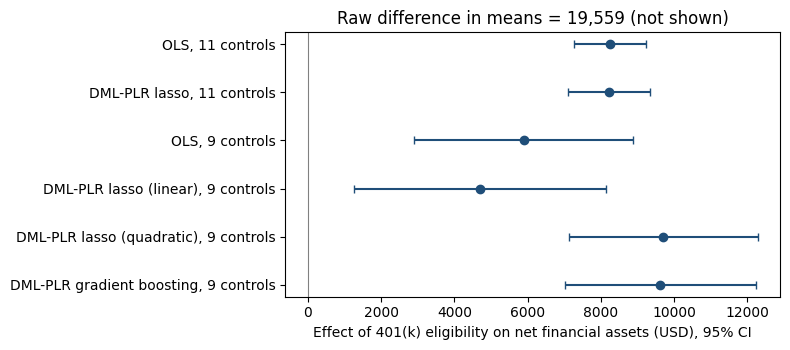

In [10]:
rows = [
    ("OLS, 11 controls", ols.params[d_col], ols.std_errors[d_col]),
    ("DML-PLR lasso, 11 controls", plr.estimate, plr.se),
    ("OLS, 9 controls", ols_base.params[d_col], ols_base.std_errors[d_col]),
    ("DML-PLR lasso (linear), 9 controls", plr_base.estimate, plr_base.se),
    ("DML-PLR lasso (quadratic), 9 controls", plr_poly.estimate, plr_poly.se),
    ("DML-PLR gradient boosting, 9 controls", plr_gbm.estimate, plr_gbm.se),
]
labels, est, ses = zip(*rows)
pos = np.arange(len(rows))[::-1]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.errorbar(est, pos, xerr=1.96 * np.array(ses), fmt="o", color="#1f4e79", capsize=3)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Effect of 401(k) eligibility on net financial assets (USD), 95% CI")
ax.set_title("Raw difference in means = " + f"{naive:,.0f}" + " (not shown)")
fig.tight_layout()
plt.show()

## 9. IRM、ATTE 与重叠条件

PLR 假定处理效应对所有人相同。**交互回归模型（IRM）** 放松了这一点。

$$
Y = g_0(D, X) + U, \qquad D = m_0(X) + V,
$$

处理效应 $g_0(1, X) - g_0(0, X)$ 可以随 $X$ 任意变化。ATE 的正交得分就是 AIPW（双重稳健）得分

$$
\psi = \hat g(1, X) - \hat g(0, X) + \frac{D\,(Y - \hat g(1, X))}{\hat m(X)} - \frac{(1 - D)\,(Y - \hat g(0, X))}{1 - \hat m(X)} - \theta.
$$

倾向得分 $\hat m(X)$ 出现在分母上，所以 IRM 需要**重叠条件**，即 $0 < m_0(X) < 1$。倾向得分贴近 0 或 1 的观测会得到极大的权重，估计量会变得很不稳定。`sp.dml` 默认把倾向得分截断到 $[0.01, 0.99]$，与 DoubleML 的默认值相同，可以用 `trimming_threshold=` 调整。

`score="ATTE"` 把估计对象换成处理组的平均处理效应。

PLR  theta :   9622.3  (se 1333.3)
IRM  ATE   :   7960.5  (se 1393.0)
IRM  ATTE  :  10235.8  (se 2525.4)


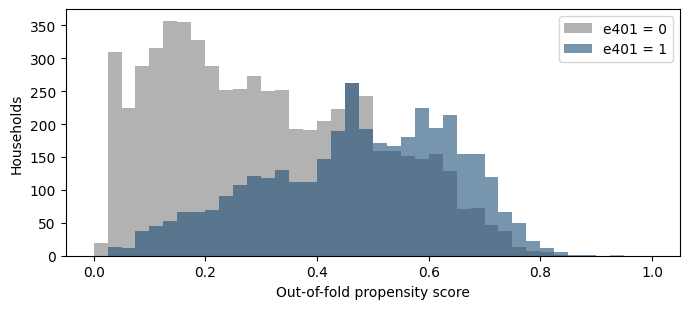

pscore_max                0.9379
n_clipped_above                0
pscore_min                0.0173
pscore_p01                0.0317
n_clipped_below                0
n_subgroup_fallback_g0         0
n_subgroup_fallback_g1         0
pscore_p99                0.7578
weighted                   False
dtype: object

In [11]:
irm_ate = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="irm",
                 ml_g="gbm", ml_m="gbm", n_folds=5, random_state=42, store_oof=True)
irm_att = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="irm",
                 ml_g="gbm", ml_m="gbm", n_folds=5, random_state=42, score="ATTE")

print(f"PLR  theta : {plr_gbm.estimate:8.1f}  (se {plr_gbm.se:.1f})")
print(f"IRM  ATE   : {irm_ate.estimate:8.1f}  (se {irm_ate.se:.1f})")
print(f"IRM  ATTE  : {irm_att.estimate:8.1f}  (se {irm_att.se:.1f})")

# store_oof=True 保留样本外的倾向得分，用来检查重叠
oof = irm_ate.get_oof().to_frame()
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, 1, 41)
ax.hist(oof.loc[oof["d"] == 0, "ps_used"], bins=bins, alpha=0.6, label="e401 = 0", color="#7f7f7f")
ax.hist(oof.loc[oof["d"] == 1, "ps_used"], bins=bins, alpha=0.6, label="e401 = 1", color="#1f4e79")
ax.set_xlabel("Out-of-fold propensity score")
ax.set_ylabel("Households")
ax.legend()
fig.tight_layout()
plt.show()
pd.Series(irm_ate.model_info["diagnostics"]).map(lambda v: round(v, 4) if isinstance(v, float) else v)

三个数字回答的是三个不同的问题，不必相等。

- ATTE 高于 ATE。有资格的家庭收入更高，如果资格的效应随收入上升，就会出现这样的排序。
- PLR 的 $\theta$ 在效应异质时是一个以条件方差 $\mathrm{Var}(D \mid X)$ 为权重的加权平均，一般不等于 ATE。
- 三者的置信区间彼此重叠。相对于各自的标准误，这些差别并不大。

重叠情况良好。两组的倾向得分分布大面积重合，没有观测被截断（`n_clipped_below` 和 `n_clipped_above` 都是 0）。如果这里出现大量贴边的观测，IRM 的结果就不该直接采信。

## 10. 样本分割的随机性

交叉拟合的划分是随机的。不同的 `random_state` 会给出不同的点估计，这是 DML 固有的一层额外噪声，与抽样误差无关。

先看它有多大。

In [12]:
by_seed = pd.DataFrame(
    [
        (s, r.estimate, r.se)
        for s in range(5)
        for r in [sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="plr",
                         ml_g="gbm", ml_m="gbm", n_folds=5, random_state=s)]
    ],
    columns=["random_state", "estimate", "se"],
).set_index("random_state")
print(f"range across seeds: {by_seed['estimate'].max() - by_seed['estimate'].min():.0f}"
      f"   (typical se: {by_seed['se'].mean():.0f})")
by_seed.round(1)

range across seeds: 1147   (typical se: 1446)


,estimate,se
random_state,,
0,9752.6,1425.8
1,9010.0,1487.6
2,10157.0,1396.7
3,9168.6,1442.6
4,9254.9,1479.3


五个种子之间的极差超过一千美元，接近一个标准误。划分是研究者可以随意更换的东西，只报告其中一次的结果等于留了一条岔路。

标准做法是**重复交叉拟合**。`n_rep=R` 会用 $R$ 个不同的划分各估一次，点估计取中位数。方差取 $\text{se}_r^2 + (\hat\theta_r - \hat\theta_{\text{med}})^2$ 的中位数，把划分之间的离散也计了进去，所以标准误通常比单次划分略大。

In [13]:
plr_rep = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="plr",
                 ml_g="gbm", ml_m="gbm", n_folds=5, n_rep=5, random_state=42)
print(f"single split (seed 42) : {plr_gbm.estimate:8.1f}  (se {plr_gbm.se:.1f})")
print(f"n_rep = 5, median      : {plr_rep.estimate:8.1f}  (se {plr_rep.se:.1f})")

single split (seed 42) :   9622.3  (se 1333.3)
n_rep = 5, median      :   9160.6  (se 1560.4)


正式的分析建议用 `n_rep` 至少 5 到 10，并在论文里写明折数、重复次数和种子。

## 11. 标准设定下再与 DoubleML 对照

第 6 节的对照是在 11 个控制变量上做的。这里在 9 变量的标准设定上、用灵活的学习器再做一次。

要让两个引擎逐位一致，需要两个条件。

- **同一个学习器。** 学习器自身的随机性也要固定。字符串简写由各包自己实例化，所以这里显式传入带 `random_state` 的估计器对象。
- **同一个划分。** PLR 上，`sp.dml(random_state=42)` 与 `np.random.seed(42)` 之后的 DoubleML 恰好得到同一个 `KFold` 划分。IRM 上两个引擎都按处理状态分层，但各自抽出的划分不同。办法是把 DoubleML 实际用的那组折取出来，通过 `fold_indices=` 原样交给 `sp.dml`。

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor


def gbr():
    return GradientBoostingRegressor(random_state=0)


def gbc():
    return GradientBoostingClassifier(random_state=0)


sp_plr = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="plr",
                ml_g=gbr(), ml_m=gbr(), n_folds=5, random_state=42)
sp_irm = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="irm",
                ml_g=gbr(), ml_m=gbc(), n_folds=5, random_state=42)

dd_base = dml.DoubleMLData(df, y_col=y_col, d_cols=d_col, x_cols=base_covs)
np.random.seed(42)
dm_plr = dml.DoubleMLPLR(dd_base, ml_l=gbr(), ml_m=gbr(), n_folds=5).fit()
np.random.seed(42)
dm_irm = dml.DoubleMLIRM(dd_base, ml_g=gbr(), ml_m=gbc(), n_folds=5).fit()

# 把 DoubleML 在 IRM 上实际用的那组折原样交给 sp.dml
folds = np.empty(len(df), dtype=int)
for k, (_, test) in enumerate(dm_irm.smpls[0]):
    folds[test] = k
sp_irm_shared = sp.dml(data=df, y=y_col, treat=d_col, covariates=base_covs, model="irm",
                       ml_g=gbr(), ml_m=gbc(), n_folds=5, fold_indices=folds)

compare_base = pd.DataFrame(
    {
        "StatsPAI estimate": [sp_plr.estimate, sp_irm.estimate, sp_irm_shared.estimate],
        "StatsPAI se": [sp_plr.se, sp_irm.se, sp_irm_shared.se],
        "DoubleML estimate": [dm_plr.coef[0], dm_irm.coef[0], dm_irm.coef[0]],
        "DoubleML se": [dm_plr.se[0], dm_irm.se[0], dm_irm.se[0]],
    },
    index=["PLR", "IRM (ATE), own folds", "IRM (ATE), shared folds"],
)
compare_base["|diff| estimate"] = (compare_base["StatsPAI estimate"] - compare_base["DoubleML estimate"]).abs()
compare_base["|diff| / se"] = compare_base["|diff| estimate"] / compare_base["StatsPAI se"]
compare_base.round(4)

,StatsPAI estimate,StatsPAI se,DoubleML estimate,DoubleML se,|diff| estimate,|diff| / se
PLR,9683.5913,1327.2050,9683.5913,1327.2050,0.0000,0.0000
"IRM (ATE), own folds",7946.9365,1388.8649,8306.7681,1497.0673,359.8316,0.2591
"IRM (ATE), shared folds",8306.7681,1497.0673,8306.7681,1497.0673,0.0000,0.0000


**PLR 逐位一致。** 学习器换成梯度提升树，控制变量换成 9 个，结论不变。两个引擎在同一个划分上用同一个学习器计算同一个得分，差距为零。

**IRM 在各自的划分下不一致。** 第二行里两个引擎用的是各自抽出的折，差距是零点几个标准误。这就是第 10 节讨论的划分噪声，第 6 节 IRM 那一行的差距也是同一个来源。

**IRM 在共享划分下同样逐位一致。** 第三行把 DoubleML 的折交给 `sp.dml` 之后，点估计和标准误的差距都归零。这说明两个引擎的 AIPW 得分本身没有分歧，之前的差距完全来自划分。

所以比较两个 DML 实现时要分清两件事。各跑各的划分，比的是划分噪声。共享划分和学习器，比的才是实现。更多讨论见 `docs/guides/sp_dml_vs_doubleml.md`。

## 12. 从资格到参与：用 IIVM 估计 LATE

到目前为止估计的都是**资格**的效应。有资格的家庭并不都参加，所以政策上更关心的往往是**实际参加** 401(k) 的效应。

参加（`p401`）是内生的。办法是用资格 `e401` 作工具变量，对应的 DML 模型是**交互工具变量模型（IIVM）**，估计的是局部平均处理效应（LATE）。需要的假设有三个。

- **条件独立。** 给定 $X$，资格与潜在结果独立。这就是第 1 节的识别假设。
- **排他性。** 资格只通过"是否参加"影响金融资产。
- **单调性。** 不存在"有资格反而不参加、没资格反而参加"的人。

先看一眼处理与工具的交叉表。

In [15]:
print(pd.crosstab(df["e401"], df["p401"]))

late = sp.dml(data=df, y=y_col, treat="p401", covariates=base_covs, model="iivm",
              instrument="e401", ml_g="gbm", ml_m="gbm", ml_r="gbm",
              n_folds=5, random_state=42)
takeup = df.loc[df["e401"] == 1, "p401"].mean()
print(f"\ntake-up among the eligible : {takeup:.3f}")
print(f"ITT  (IRM ATE of e401)     : {irm_ate.estimate:8.1f}  (se {irm_ate.se:.1f})")
print(f"LATE (IIVM, p401 ~ e401)   : {late.estimate:8.1f}  (se {late.se:.1f})")
print(f"ITT / take-up (rough check): {irm_ate.estimate / takeup:8.1f}")

p401     0     1
e401            
0     6233     0
1     1088  2594



take-up among the eligible : 0.705
ITT  (IRM ATE of e401)     :   7960.5  (se 1393.0)
LATE (IIVM, p401 ~ e401)   :  11342.5  (se 1982.9)
ITT / take-up (rough check):  11299.4


交叉表显示没有资格的家庭**没有一个**参加，这是单侧不依从。此时单调性自动成立，依从者恰好就是全部参加者，LATE 可以解读为**参加 401(k) 对参加者的平均效应**。

LATE 大于 ITT，逻辑很直接。有资格的家庭里大约七成实际参加，资格的效应全部由这七成人贡献，摊回到参加者身上自然更大。最后一行用 ITT 除以参加率做了一个粗略的核对，与 IIVM 的估计很接近。两者不会完全相等，因为 IIVM 是在 $X$ 的每个取值上分别做这个除法再平均。

`ml_r` 是工具变量方程的学习器。`sp.dml` 的 `pliv` 和 `iivm` 目前只接受单个标量工具变量。

## 13. 未观测混淆的敏感性

前面所有的估计都依赖"给定 $X$ 后资格与潜在结果独立"。这个假设无法检验，但可以问一个可以回答的问题。**未观测到的混淆因素要有多强，才能推翻结论？**

`sp.dml_sensitivity` 实现了 Chernozhukov, Cinelli, Newey, Sharma & Syrgkanis (2022) 的遗漏变量偏误界。混淆的强度用两个偏 $R^2$ 刻画。

- `cf_y`，未观测混淆能解释的结果残差方差的比例。
- `cf_d`，它能解释的处理残差方差的比例。

输出的**稳健值** `RV_q` 是让估计值缩小 $q$ 倍所需的最小混淆强度（两个偏 $R^2$ 取相同的值）。$q=1$ 对应把估计值压到零。

In [16]:
sens = sp.dml_sensitivity(plr_gbm, q=1.0, cf_y=0.03, cf_d=0.03)
print(sens.summary())

DML-OVB (Chernozhukov-Cinelli-Newey 2022)
----------------------------------------------------------------
  Original estimate                : +9622.2796 (SE 1333.3073)
  Robustness value RV_q (q=1.0)   : 0.0756   (7.56% partial R^2 to shrink to 0%)
  Robustness value RV_qa (alpha=0.05)   : 0.0556   (strength to lose significance)
  Bias bound (cf_y=0.030, cf_d=0.030) : 3728.8438
  Adjusted estimate range          : [+5893.4358, +13351.1234]

  Reference: Chernozhukov V., Cinelli C., Newey W., Sharma A.,
  Syrgkanis V. (2022). 'Long Story Short.' arXiv:2112.13398.


读法如下。

- `RV_q` 是把点估计压到零所需的混淆强度。未观测因素要同时解释结果残差和处理残差各这么大比例的方差才做得到。
- `RV_qa` 是让结论失去 5% 显著性所需的强度，门槛更低。
- 设定 `cf_y = cf_d = 0.03` 的情景下，偏误界与调整后的估计区间一并给出。区间下端仍然为正，说明这个强度的混淆不足以改变符号。

这些数字本身不告诉你假设是否成立。它们的用处是把争论变得具体。读者如果认为存在某个遗漏变量，比如储蓄偏好，就需要论证它在控制了收入、年龄、教育之后还能解释这么多残差方差。

## 14. 小结与练习

### 这份数据告诉我们什么

- 原始均值差接近 2 万美元，其中一多半是选择偏误。
- 在 9 个控制变量的标准设定下，用灵活的学习器，资格对净金融资产的效应约为 8 千到 1 万美元，与 DoubleML 和 `hdm` 文献的量级一致。
- 参加 401(k) 对参加者的效应更大，约 1.1 万美元。
- 给定同一个学习器和同一组折，`sp.dml` 与 `doubleml-for-py` 在 PLR 和 IRM 上都逐位一致。各用各的划分时 IRM 会相差零点几个标准误，那是划分噪声。

### 做 DML 时的自查清单

1. **控制变量都是处理前变量吗？** 结果的组成部分和可能受处理影响的变量不要放进去。
2. **干扰函数拟合得够好吗？** 看样本外 $R^2$，并且至少换两种学习器。
3. **重叠条件成立吗？** 用 IRM 时检查倾向得分分布和被截断的观测数。
4. **结果依赖某一次划分吗？** 用 `n_rep` 做重复交叉拟合。
5. **估计对象说清楚了吗？** $\theta$、ATE、ATTE、LATE 各回答不同的问题。
6. **识别假设有多脆弱？** 报告敏感性分析。

DML 解决的是函数形式问题，不解决识别问题。条件独立假设不成立时，再好的学习器也救不回来。

### 练习

1. 把第 8 节的学习器换成 `'rf'`（随机森林）。估计值和样本外 $R^2$ 落在哪里？运行时间有什么变化？
2. 第 9 节用的是 `trimming_threshold=0.01`。改成 `0.05` 和 `0.1`，IRM 的 ATE 变化大吗？这说明了什么？
3. 用 `n_folds=2` 和 `n_folds=10` 各跑一次 PLR。折数对点估计和标准误有什么影响？
4. `pira`（参加 IRA）和 `hown`（自有住房）严格来说也可能受 401(k) 资格影响。把它们从控制集里拿掉，结果怎么变？你会如何为保留或剔除它们辩护？
5. 把结果变量换成 `tw`（总财富），控制变量用 `base_covs`。资格对总财富的效应与对净金融资产的效应相比如何？这对"401(k) 是否挤出其他储蓄"意味着什么？

### 参考文献

下列条目已逐条核验。方括号里是 `paper.bib` 中的 bib key，可以用 `sp.bibtex()` 取出 BibTeX。

- Chernozhukov, V. & Hansen, C. (2004). The Effects of 401(K) Participation on the Wealth Distribution: An Instrumental Quantile Regression Analysis. *Review of Economics and Statistics*, 86(3), 735–751. doi [`10.1162/0034653041811734`](https://doi.org/10.1162/0034653041811734).
- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W. & Robins, J. (2018). Double/Debiased Machine Learning for Treatment and Structural Parameters. *The Econometrics Journal*, 21(1), C1–C68. doi [`10.1111/ectj.12097`](https://doi.org/10.1111/ectj.12097). [`chernozhukov2018double`]
- Chernozhukov, V., Hansen, C. & Spindler, M. (2016). hdm: High-Dimensional Metrics. *The R Journal*, 8(2), 185–199. doi [`10.32614/RJ-2016-040`](https://doi.org/10.32614/RJ-2016-040). [`chernozhukov2016hdm`]
- Bach, P., Chernozhukov, V., Kurz, M. S. & Spindler, M. (2022). DoubleML: An Object-Oriented Implementation of Double Machine Learning in Python. *Journal of Machine Learning Research*, 23(53), 1–6. <https://jmlr.org/papers/v23/21-0862.html>. [`bach2022doubleml`]
- Chernozhukov, V., Cinelli, C., Newey, W., Sharma, A. & Syrgkanis, V. (2022). Long Story Short: Omitted Variable Bias in Causal Machine Learning. NBER Working Paper 30302. doi [`10.3386/w30302`](https://doi.org/10.3386/w30302). arXiv:2112.13398. [`chernozhukov2022long`]